In [ ]:
import sys
from pathlib import Path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent

import networkx as nx
sys.path.append(str(ROOT))
from torch_geometric.utils import degree
import torch
from torch_geometric.datasets import Planetoid
from src.models.mlp import MLP
from src.plotting import visualize_embeddings_grid
from src.models.svm import evaluate_with_svm
from node2vec import Node2Vec
from src.methods.posEnc import LaplacianPosEnc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device: ", device)
dataset = Planetoid(root='~/datasets/PubMed', name='PubMed')
data = dataset[0]
data = data.to(device)
print(data)

deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
print(f"Avg Degree: {deg.mean().item():.2f}")

device:  cpu
Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])
Number of nodes: 19717
Number of edges: 88648
PubMed - Avg Degree: 4.50


In [4]:
# node2vec

G = nx.Graph()

G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(data.edge_index.t().tolist())

node2vec = Node2Vec(G, 
            dimensions=64,
            walk_length=40, 
            num_walks=25,
            p = 1.0, 
            q = 0.5,
            workers=5)

model = node2vec.fit(window = 10, min_count=1, batch_words=5)
emb_node2vec = torch.tensor([model.wv[str(n)] for n in range(data.num_nodes)])

print(emb_node2vec.shape) 

Computing transition probabilities:   0%|          | 0/19717 [00:00<?, ?it/s]

Generating walks (CPU: 5): 100%|██████████| 5/5 [00:14<00:00,  2.83s/it]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_

torch.Size([19717, 64])


/var/folders/t_/hzd73tvn4xj14njtt5ztk4dr0000gn/T/ipykernel_32133/2682542193.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  emb_node2vec = torch.tensor([model.wv[str(n)] for n in range(data.num_nodes)])


In [5]:
# posEnc

pos_enc = LaplacianPosEnc(k=32)
data_posEnc = pos_enc(data)
emb_posEnc = data_posEnc.x

print(emb_posEnc.shape)

torch.Size([19717, 532])


In [6]:
# original embeddings
emb_original = data.x.clone().to(device)
print(emb_original)


tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  2.4660e-03,
          1.7411e-03, -3.8075e-04],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -3.6112e-03,
         -5.7645e-04,  2.0497e-04],
        [ 1.0464e-01,  0.0000e+00,  0.0000e+00,  ...,  3.6596e-04,
          9.3328e-05,  3.0062e-04],
        ...,
        [ 0.0000e+00,  1.9427e-02,  7.9607e-03,  ..., -2.8591e-03,
         -1.7529e-03, -3.9528e-04],
        [ 1.0782e-01,  0.0000e+00,  0.0000e+00,  ...,  1.3411e-03,
          7.3982e-04, -4.6094e-03],
        [ 0.0000e+00,  2.6584e-02,  0.0000e+00,  ...,  1.5768e-02,
          2.5776e-03, -7.7687e-04]])


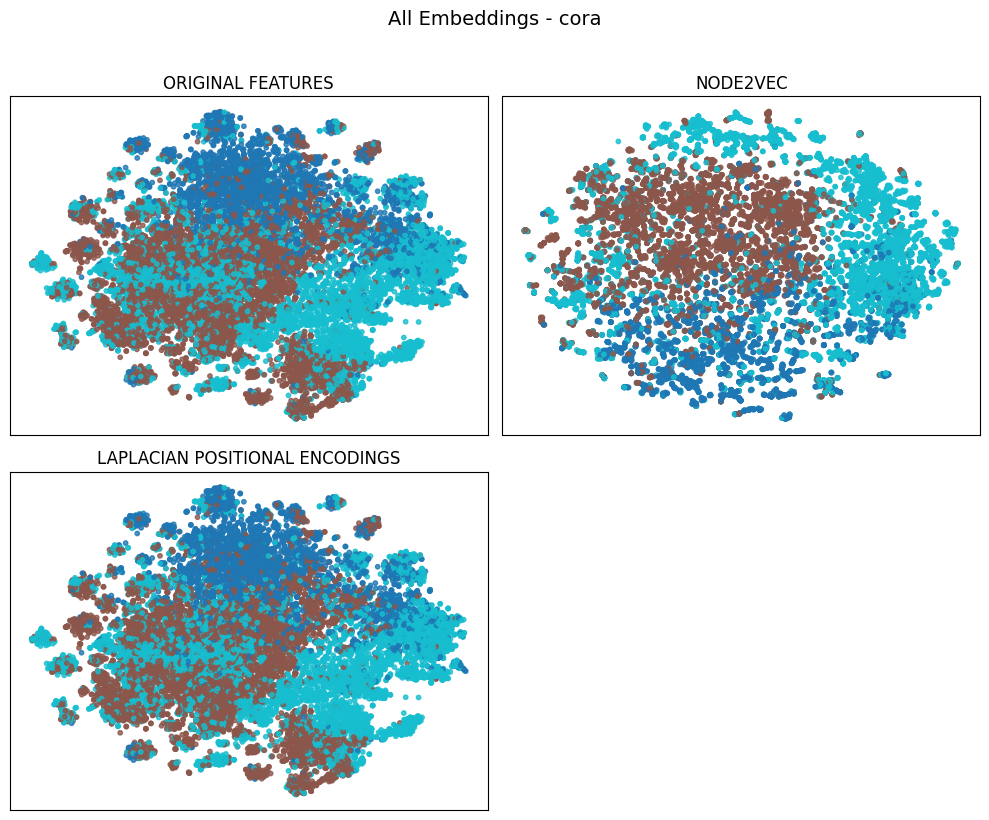

In [7]:
labels = data.y
all_embeddings = {
    "Original Features": emb_original.cpu(),
    "Node2Vec": emb_node2vec.cpu(),
    "Laplacian Positional Encodings": emb_posEnc.cpu()
}
visualize_embeddings_grid(all_embeddings, labels, title= "All Embeddings")



MLP on LAPLACIANPOSENC embeddings
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=1e-05 | Val 0.6880
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0001 | Val 0.6920
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0005 | Val 0.6680
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=1e-05 | Val 0.6920
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0001 | Val 0.6960
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0005 | Val 0.6980
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=1e-05 | Val 0.7060
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0001 | Val 0.6940
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0005 | Val 0.7000
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=1e-05 | Val 0.7000
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0001 | Val 0.7080
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0005 | Val 0.6840
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.001, wd=1e-05 | Val 0.7220
[L

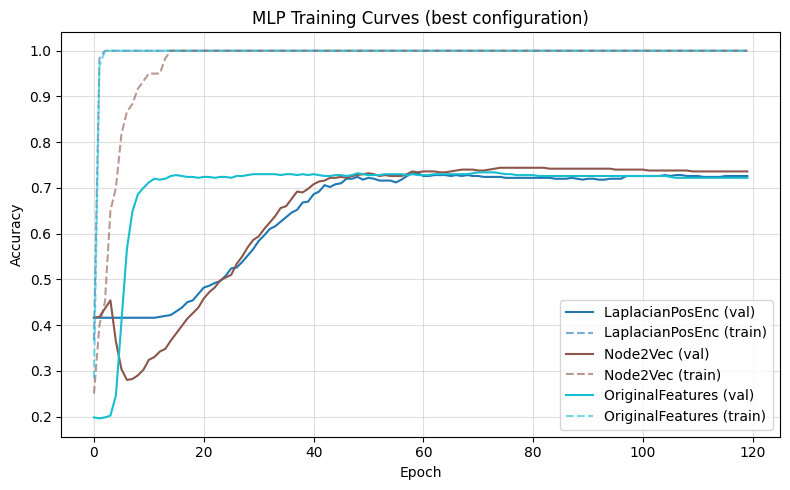

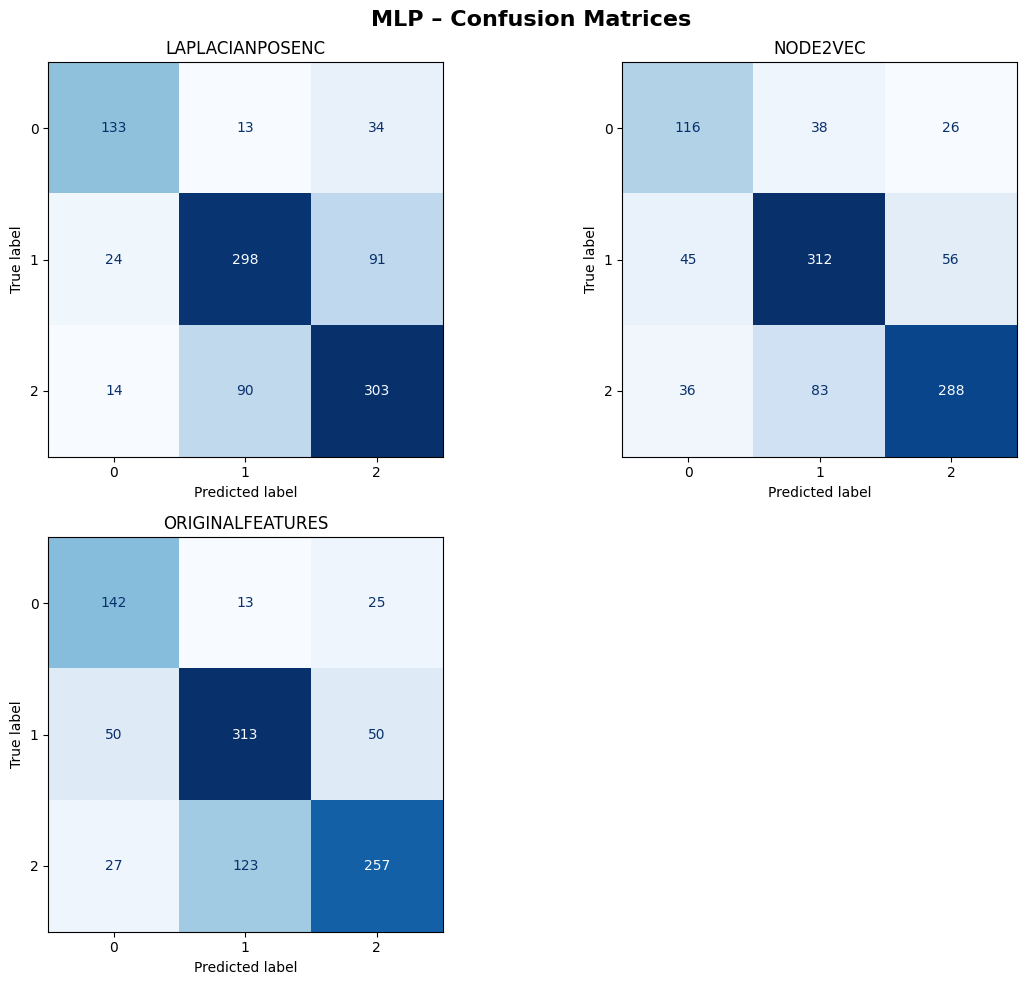

In [ ]:
# evaluate with MLP

results_dir = Path("/Users/emely/Uni/Thesis/Thesis/PubMed/results")
results_dir.mkdir(parents=True, exist_ok=True)

embeddings = {"LaplacianPosEnc": emb_posEnc, "Node2Vec": emb_node2vec, "OriginalFeatures": emb_original}

best_results, best_acc = MLP.evaluate_with_mlp(
    embeddings=embeddings,
    data=data,
    device=device,
    mlp_epochs=120
)

torch.save(best_acc, results_dir / "best_acc_node_pos.pt")
emb_file = Path("/Users/emely/Uni/Thesis/Thesis/PubMed/results/embeddings.pt")

if emb_file.exists():
    all_embeddings = torch.load(emb_file)
else:
    all_embeddings = {}

for name, emb_tensor in embeddings.items():
    all_embeddings[name] = {name: emb_tensor.detach().cpu()}

torch.save(all_embeddings, emb_file)


SVM on LAPLACIANPOSENC embeddings
C=0.01 | Val Acc=0.7340
C=0.1 | Val Acc=0.7360
C=1 | Val Acc=0.7240
C=10 | Val Acc=0.7200
Best C=0.1 | Test Acc=0.7290


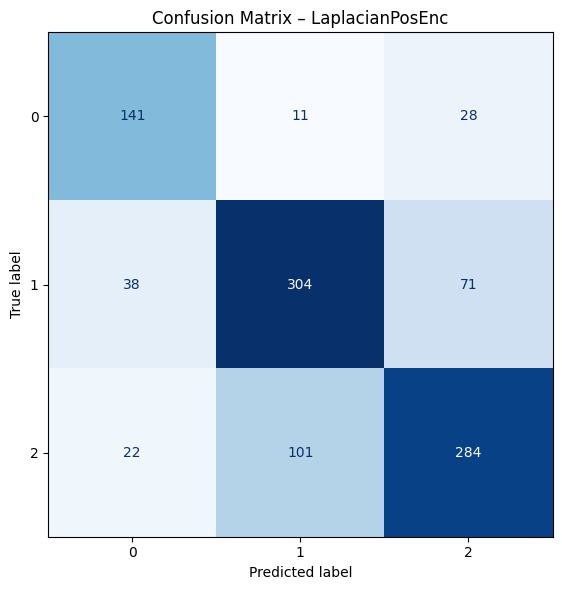


SVM on NODE2VEC embeddings
C=0.01 | Val Acc=0.7420
C=0.1 | Val Acc=0.7580
C=1 | Val Acc=0.7420
C=10 | Val Acc=0.6980
Best C=0.1 | Test Acc=0.7450


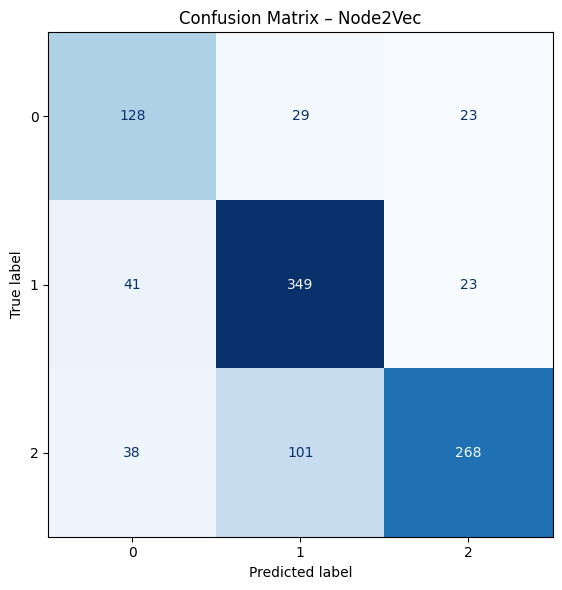


SVM on ORIGINALFEATURES embeddings
C=0.01 | Val Acc=0.7340
C=0.1 | Val Acc=0.7360
C=1 | Val Acc=0.7240
C=10 | Val Acc=0.7200
Best C=0.1 | Test Acc=0.7290


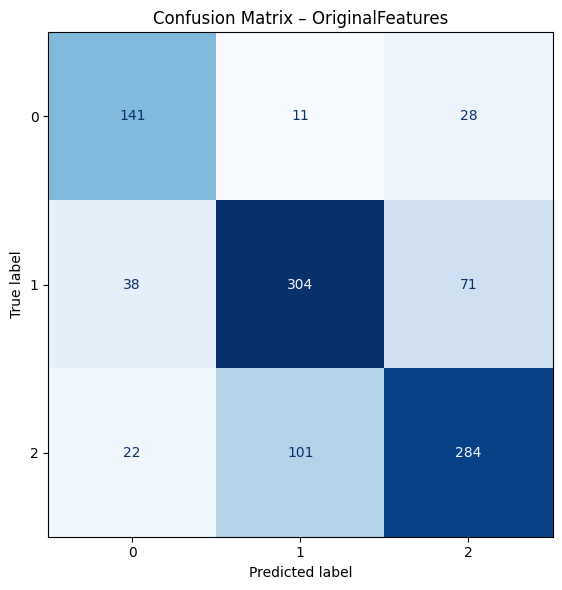

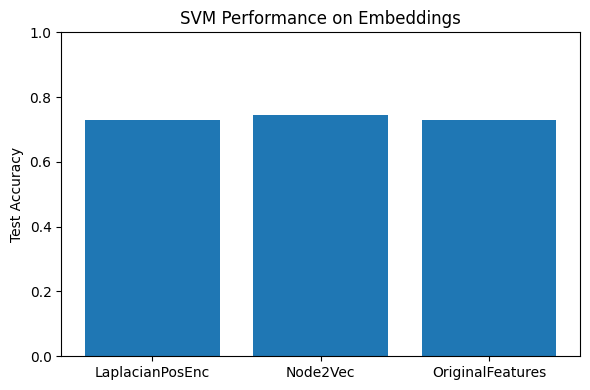

In [ ]:
# evaluate with SVM

svm_results = evaluate_with_svm(
    embeddings=embeddings,
    data=data,
    device=device
)
torch.save(svm_results,"/Users/emely/Uni/Thesis/Thesis/PubMed/results/svm_results_node_pos.pt")